In [ ]:
import pandas as pd
import random as rnd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
Medicalpremium = pd.read_csv("Health_insurance.csv")#read csv file

In [ ]:
Medicalpremium.head(7) # first 3 object caming to table

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960


In [ ]:
Medicalpremium.shape #giving how many row and col information

(1338, 7)

In [ ]:
Medicalpremium.info()# it's giving attributes' type info and how many value is non null info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
Medicalpremium.sample(7)#chosing 7 random obje from my data

,age,sex,bmi,children,smoker,region,charges
699,23,female,39.270,2,no,southeast,3500.61230
1161,34,male,42.130,2,no,southeast,5124.18870
689,27,male,31.130,1,yes,southeast,34806.46770
185,36,male,41.895,3,yes,northeast,43753.33705
412,26,female,17.195,2,yes,northeast,14455.64405
399,18,female,38.170,0,no,southeast,1631.66830
139,22,female,36.000,0,no,southwest,2166.73200


In [ ]:
Medicalpremium.columns# here is the attributes' names

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
Medicalpremium.dtypes #dataset type

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [ ]:
Medicalpremium.values #Here is the all values inside in array.

array([[19, 'female', 27.9, ..., 'yes', 'southwest', 16884.924],
       [18, 'male', 33.77, ..., 'no', 'southeast', 1725.5523],
       [28, 'male', 33.0, ..., 'no', 'southeast', 4449.462],
       ...,
       [18, 'female', 36.85, ..., 'no', 'southeast', 1629.8335],
       [21, 'female', 25.8, ..., 'no', 'southwest', 2007.945],
       [61, 'female', 29.07, ..., 'yes', 'northwest', 29141.3603]],
      dtype=object)

In [ ]:
Medicalpremium.region.unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [ ]:
Medicalpremium.children.unique()

array([0, 1, 3, 2, 5, 4], dtype=int64)

In [ ]:
Medicalpremium.describe() #i can acsess five number summary for int values.In this way, I can learn about a lot of things from here, mean, median quartiles
#

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
Medicalpremium.isna().sum().sort_values(ascending=False) #here is calculated how many missing value are there .

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
# Apply value_counts() on column sex
sex = Medicalpremium['sex'].value_counts()
sex # how many male and female are they in my dataset? it is almost equal

sex
male      676
female    662
Name: count, dtype: int64

In [ ]:
# Apply value_counts() on column smoker
smoker = Medicalpremium['smoker'].value_counts()
smoker # How many people smoke ?   #that's nice non smoke people are less than  smoker people

smoker
no     1064
yes     274
Name: count, dtype: int64

In [ ]:
# Apply value_counts() on column region
region = Medicalpremium['region'].value_counts()
region

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [ ]:
print("Mid-range for children:", ((Medicalpremium['children'].min() + Medicalpremium['children'].max()) / 2)) #Mid-range = (max+min)/2
print("Mid-range for charges:", ((Medicalpremium['charges'].min() + Medicalpremium['charges'].max()) / 2))
print("Mid-range for bmi:", ((Medicalpremium['bmi'].min() + Medicalpremium['bmi'].max()) / 2))
print("Mid-range for age:", ((Medicalpremium['age'].min() + Medicalpremium['age'].max()) / 2))

Mid-range for children: 2.5
Mid-range for charges: 32446.150955
Mid-range for bmi: 34.545
Mid-range for age: 41.0


In [ ]:
print("Max-Min for children:", Medicalpremium['children'].max() - Medicalpremium['children'].min())
print("Max-Min for charges:", Medicalpremium['charges'].max() - Medicalpremium['charges'].min())
print("Max-Min for bmi:", Medicalpremium['bmi'].max() - Medicalpremium['bmi'].min())
print("Max-Min for age:", Medicalpremium['age'].max() - Medicalpremium['age'].min())

Max-Min for children: 5
Max-Min for charges: 62648.554110000005
Max-Min for bmi: 37.17
Max-Min for age: 46


In [ ]:
# IQR=Q3-Q1
age= Medicalpremium['age'].quantile([0.25, 0.5, 0.75])
print(f"IQR for age: {age[0.75] - age[0.25]}")
children= Medicalpremium['children'].quantile([0.25, 0.5, 0.75])
print(f"IQR for children: {children[0.75] - children[0.25]}")
charges= Medicalpremium['charges'].quantile([0.25, 0.5, 0.75])
print(f"IQR for charges: {charges[0.75] - charges[0.25]}")
bmi= Medicalpremium['bmi'].quantile([0.25, 0.5, 0.75])
print(f"IQR for bmi: {bmi[0.75] - bmi[0.25]}")

IQR for age: 24.0
IQR for children: 2.0
IQR for charges: 11899.625365
IQR for bmi: 8.3975


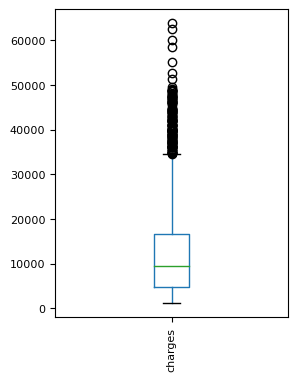

In [ ]:
#boxplot = Medicalpremium.boxplot(column=['age'],figsize = (3,4), rot = 90, fontsize= '8', grid = False)
#boxplot2 = Medicalpremium.boxplot(column=['children'],figsize = (3,4), rot = 90, fontsize= '8', grid = False)
#boxplot3 = Medicalpremium.boxplot(column=['bmi'],figsize = (3,4), rot = 90, fontsize= '8', grid = False)
boxplot3 = Medicalpremium.boxplot(column=['charges'],figsize = (3,4), rot = 90, fontsize= '8', grid = False)


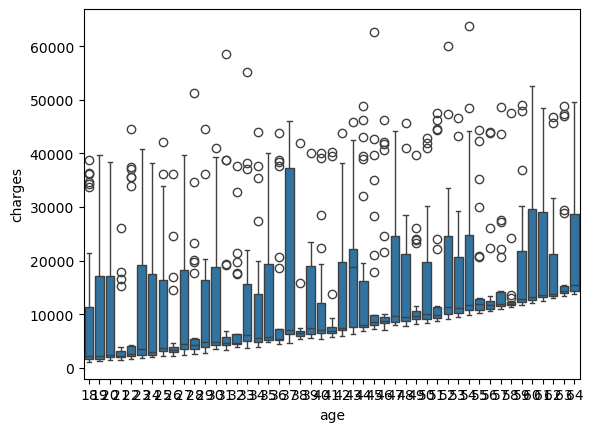

In [ ]:
sns.boxplot( x=Medicalpremium["age"], y=Medicalpremium["charges"] )
plt.show()

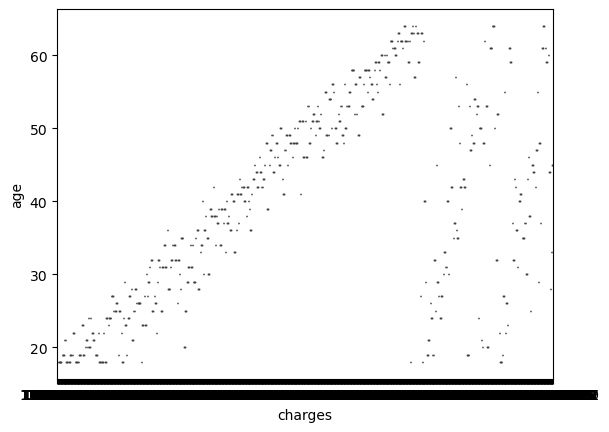

In [ ]:
sns.boxplot( x=Medicalpremium["charges"], y=Medicalpremium["age"] )   #çok değişik bir şey oldu anlamadım.
plt.show()

In [ ]:
for kolon in Medicalpremium.columns[1:]:
    if Medicalpremium[kolon].dtype == 'float64':
        print(f"Variance of {kolon} :{Medicalpremium[kolon].var()}")
for kolon in Medicalpremium.columns[1:]:
    if Medicalpremium[kolon].dtype == 'int64':
        print(f"Variance of {kolon} :{Medicalpremium[kolon].var()}")

Variance of bmi :37.187883609773266
Variance of charges :146652372.1528548
Variance of children :1.4532127456668944


In [ ]:

for kolon in Medicalpremium.columns[1:]:
    if Medicalpremium[kolon].dtype == 'float64':
        print(f"Std of {kolon} : {Medicalpremium[kolon].std()}")
for kolon in Medicalpremium.columns[1:]:
    if Medicalpremium[kolon].dtype == 'int64':
        print(f"Std of {kolon} : {Medicalpremium[kolon].std()}")

Std of bmi : 6.098186911679017
Std of charges : 12110.011236693994
Std of children : 1.2054927397819095


In [ ]:
import matplotlib.pyplot as plt
Medicalpremium['charges'].plot(kind='hist',bins=5)

<Axes: ylabel='Frequency'>

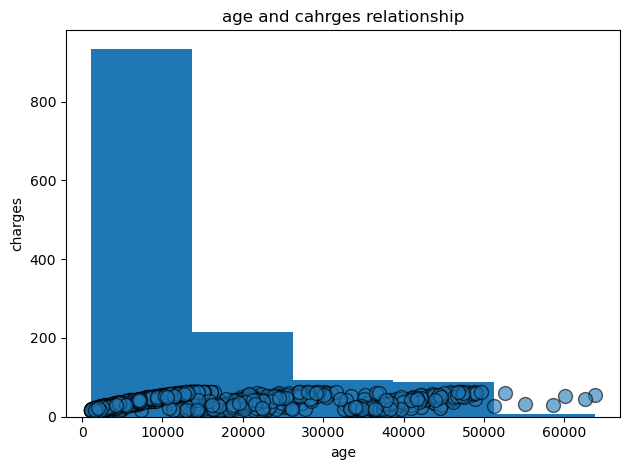

In [ ]:
view_count = Medicalpremium['charges']
x = Medicalpremium['age']
plt.scatter(view_count, x, s=100, alpha=0.6, edgecolor='black', linewidth=1)

plt.title('age and cahrges relationship')
plt.xlabel('age')
plt.ylabel('charges')

plt.tight_layout()
plt.show()


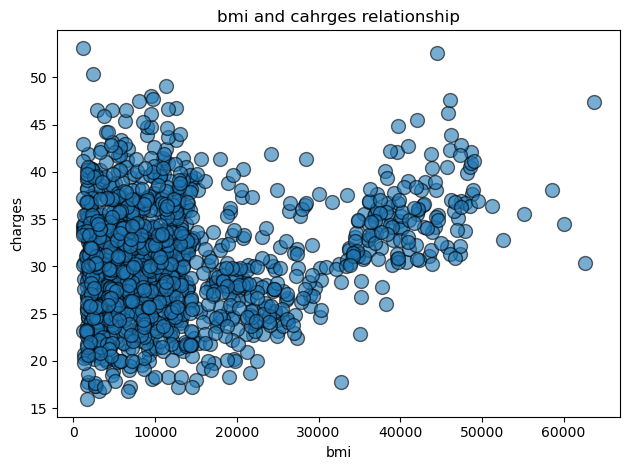

In [ ]:
view_count = Medicalpremium['charges']
x = Medicalpremium['bmi']
plt.scatter(view_count, x, s=100, alpha=0.6, edgecolor='black', linewidth=1)

plt.title('bmi and cahrges relationship')
plt.xlabel('bmi')
plt.ylabel('charges')

plt.tight_layout()
plt.show()

In [ ]:
categoric=[x for x in Medicalpremium.columns if Medicalpremium[x].dtypes=='object']
categoric

['sex', 'smoker', 'region']

In [ ]:
numeric=[y for y in Medicalpremium.columns if Medicalpremium[y].dtypes!='object']
numeric

['age', 'bmi', 'children', 'charges']

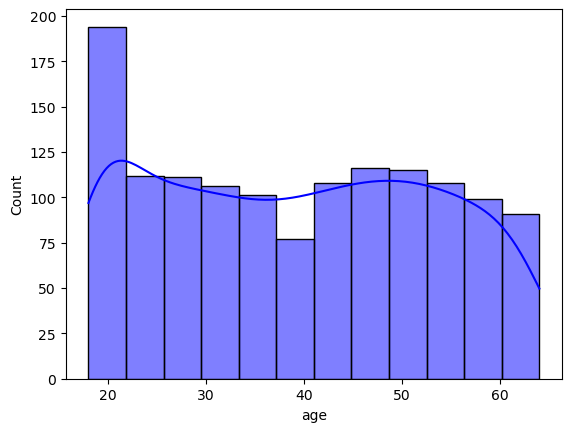

In [ ]:
sns.histplot(Medicalpremium, x='age', kde=True, color="b")
#Also i can draw all numeric columns graph like this and i can commend their shape of disrubition
plt.show()

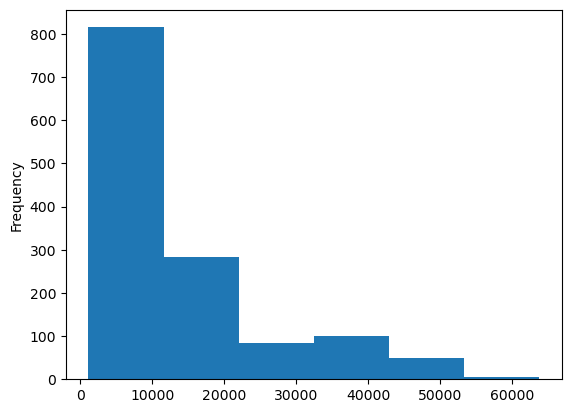

In [ ]:
import matplotlib.pyplot as plt
Medicalpremium['charges'].plot(kind='hist',bins=6)
# when i look at this table it's right skewed.
plt.show()

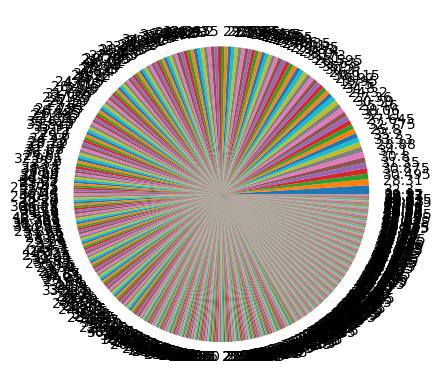

In [ ]:
Medicalpremium['bmi'].value_counts().plot.pie()# in my dataset users are mostly Mariied
plt.show()

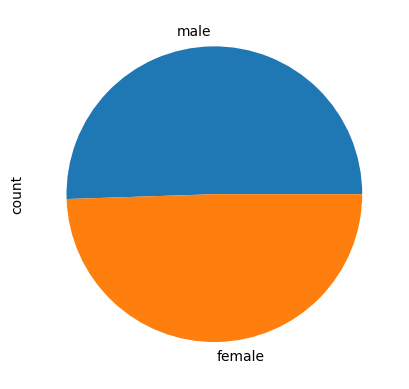

In [ ]:
Medicalpremium['sex'].value_counts().plot.pie()
plt.show()
#When i look at the graph there are it's seems %50 male %50 female but i will check the exact count

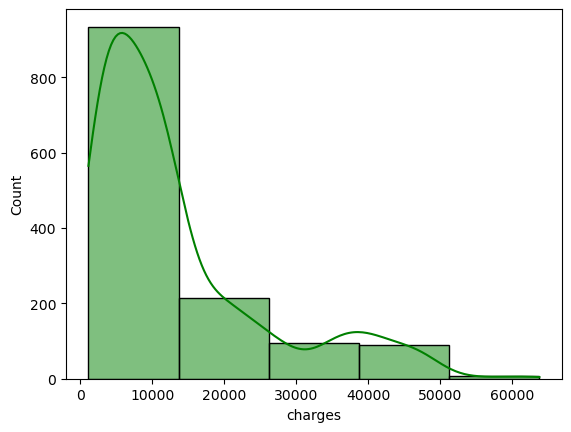

In [ ]:
sns.histplot(Medicalpremium, x='charges',bins=5, kde=True, color="g")
t=Medicalpremium['charges'].mean()
l=Medicalpremium['charges'].mode()
plt.show()
#l>t so that mode bigger than mean.left skewed

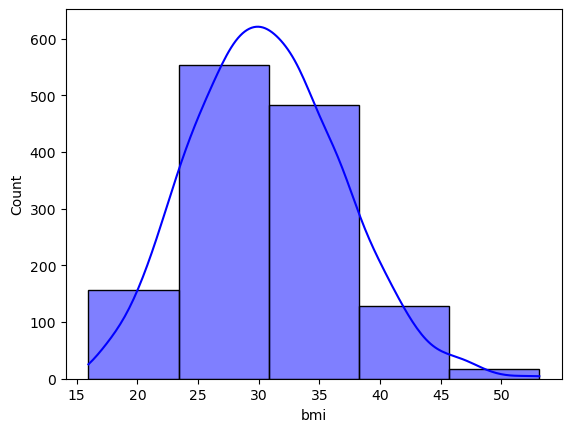

In [ ]:
sns.histplot(Medicalpremium, x='bmi',bins=5, kde=True, color="b")
plt.show()


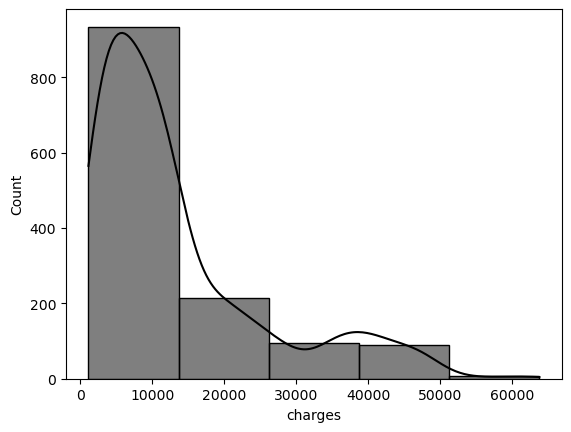

In [ ]:
sns.histplot(Medicalpremium, x='charges',bins=5, kde=True, color="k") #left skewd
plt.show()

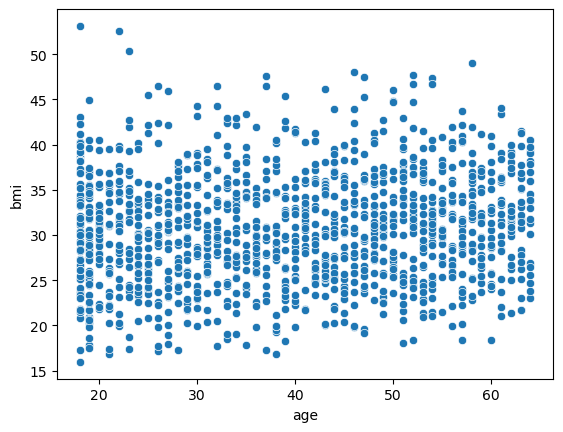

In [ ]:
island=list(Medicalpremium.groupby('charges'))

sns.scatterplot(data=Medicalpremium, x = 'age', y = 'bmi')
plt.show()


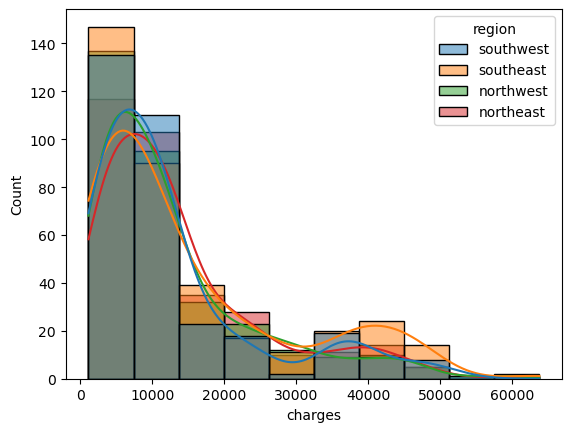

In [ ]:
sns.histplot(data=Medicalpremium, x='charges', hue='region',bins=10, kde=True, color="m")
plt.show()

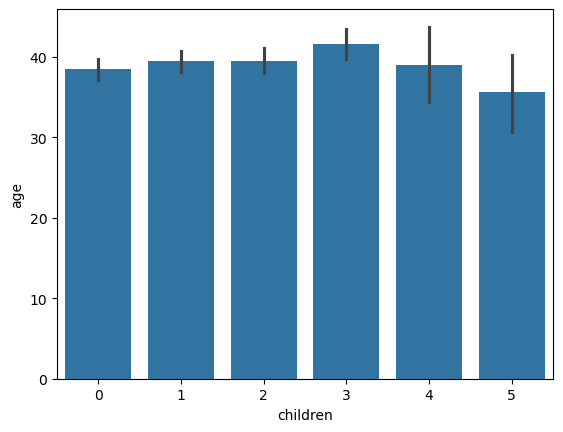

In [ ]:
sns.barplot(data=Medicalpremium, x='children', y='age')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2424\388446947.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Medicalpremium,x='children', palette="ch:.25")


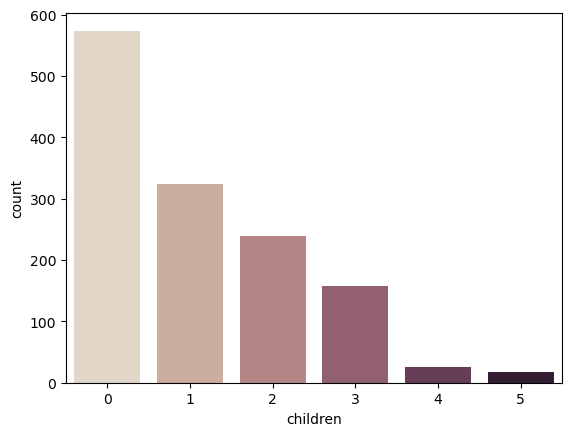

In [ ]:
sns.countplot(data=Medicalpremium,x='children', palette="ch:.25")
plt.show()

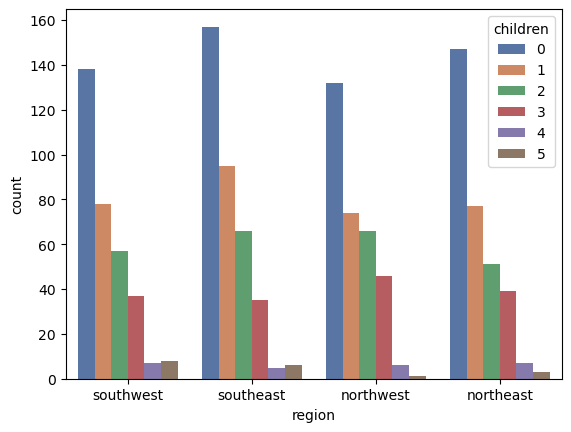

In [ ]:
sns.countplot(data=Medicalpremium,x='region', hue='children', palette='deep')
plt.show()

In [ ]:
Medicalpremium.plot(lw=0, marker=".", subplots=True, layout=(-1, 3),
          figsize=(10, 20), markersize=1);

In [ ]:
Medicalpremium['region'].value_counts().plot(kind='pie')

<Axes: ylabel='count'>

In [ ]:
new_data_copy = Medicalpremium.copy()

# in here , i crate a new database which name is new_data_copy .Cause of i don't want to change my main data to compare with new data.
#Also, i remove the  outliers from bmi.and i check again, all outliers are removed


In [ ]:
new_data_copy.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [ ]:
new_data_copy.isna().sum().sort_values(ascending=False)#i am checking is there any missing value.

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
na_counts = Medicalpremium.isna().sum()
na_counts # yok

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### b) Geçersiz özellikleri tekrar isimlendir

In [ ]:
Medicalpremium.head(5) #the columns' names are valid names there is no need to change

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


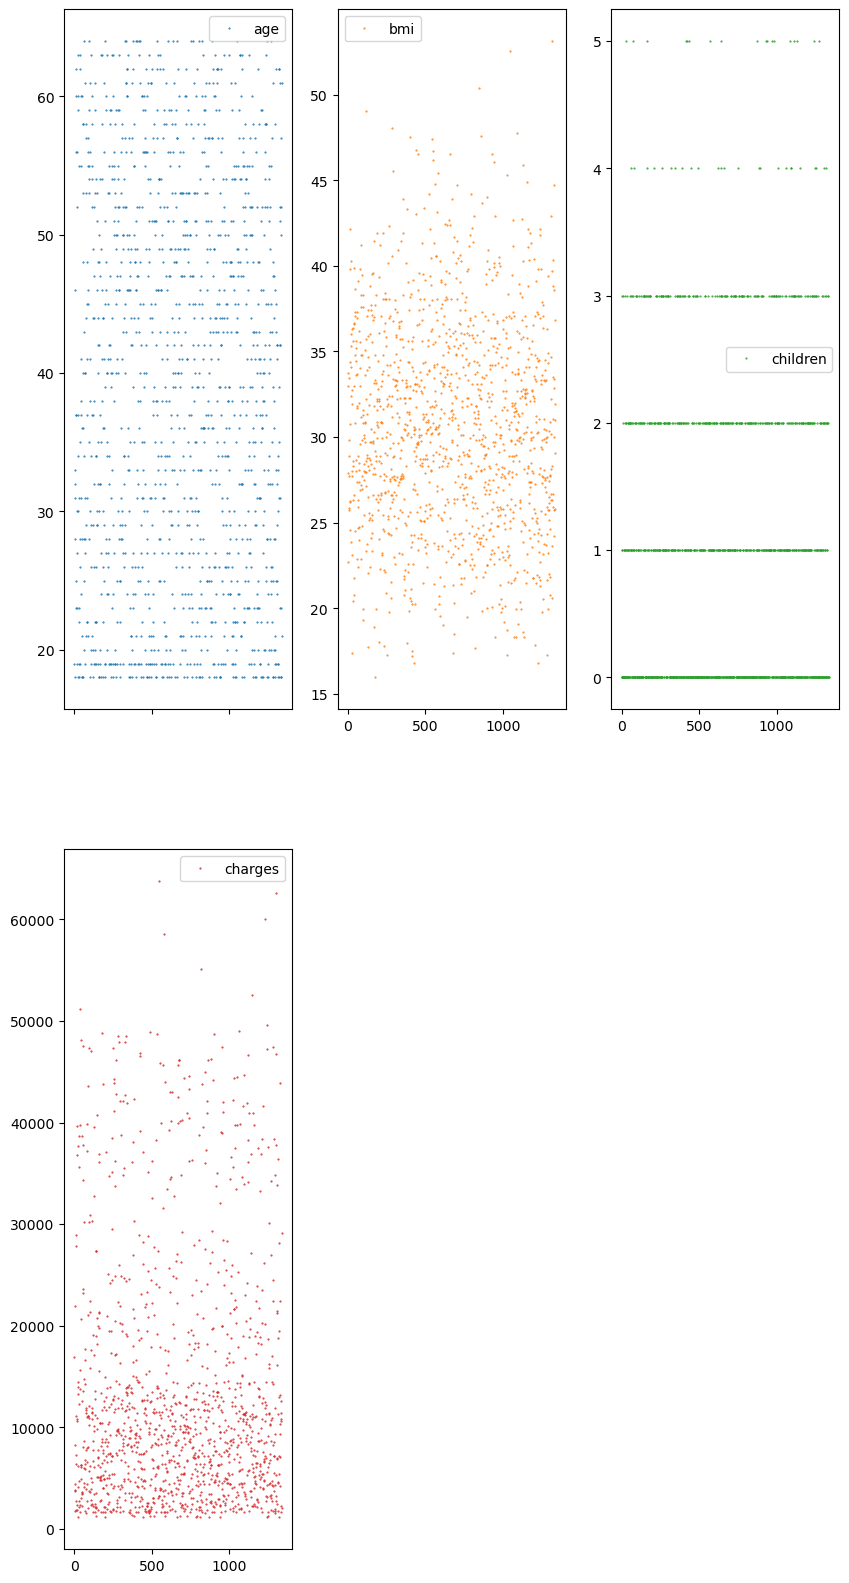

In [ ]:
boxplot = new_data_copy.boxplot(figsize = (3,4), rot = 90, fontsize= '8', grid = True)
plt.show()

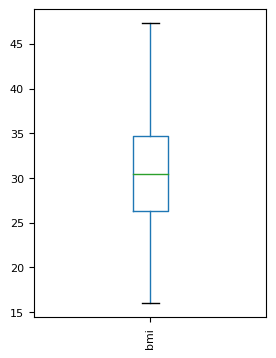

In [ ]:
import numpy as np

bmi_quantiles = Medicalpremium['bmi'].quantile([0.25, 0.5, 0.75])

q1 = bmi_quantiles.loc[0.25]
q3 = bmi_quantiles.loc[0.75]

iqr = q3 - q1

a = q3 + 1.5 * iqr

new_data_copy['bmi'] = np.where(new_data_copy['bmi'] > a, a, new_data_copy['bmi'])

boxplot = new_data_copy.boxplot(column=['bmi'], figsize=(3, 4), rot=90, fontsize=8, grid=False)

plt.show()
#all of them had been remove from new dataset.

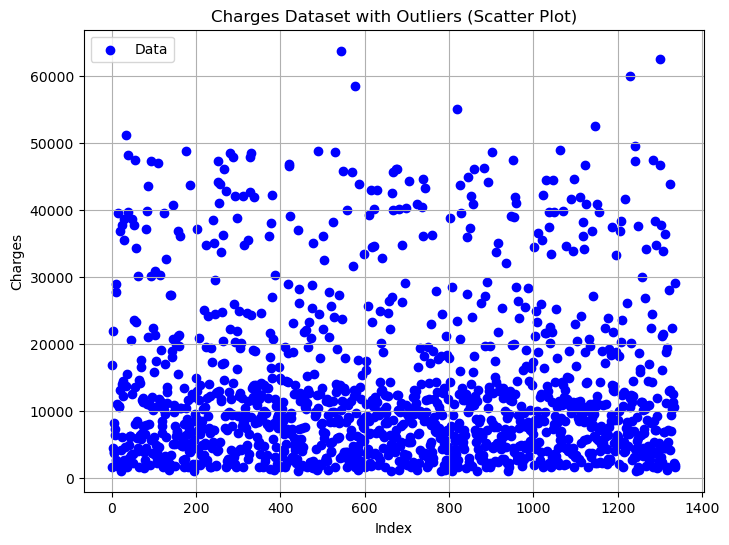

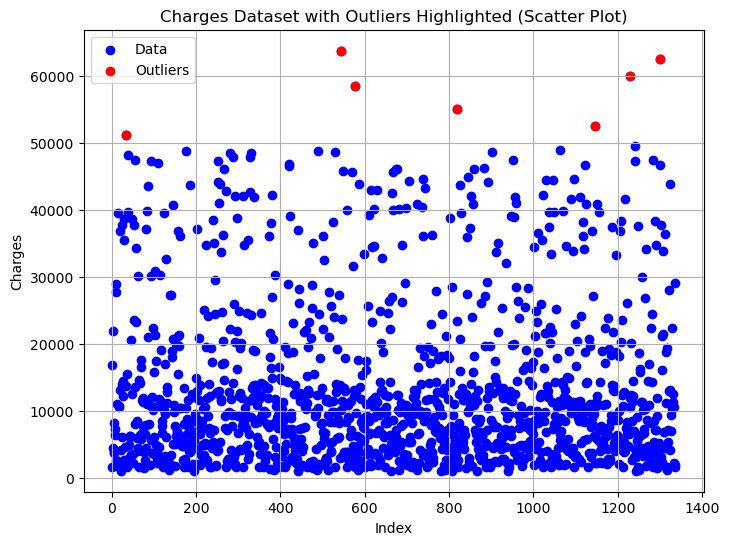

Original data shape: (1338, 7)
Cleaned data shape: (1331, 7)


In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Scatter plot ile outliers'ları göster
plt.figure(figsize=(8, 6))
plt.scatter(new_data_copy.index, new_data_copy['charges'], color='blue', label='Data')
plt.title('Charges Dataset with Outliers (Scatter Plot)')
plt.xlabel('Index')
plt.ylabel('Charges')
plt.legend()
plt.grid(True)
plt.show()

# Z-skorunu hesaplayarak outliers'ları belirleme
z_scores = zscore(new_data_copy['charges'])
outliers_mask = (z_scores < -3) | (z_scores > 3)

# Scatter plot üzerinde uç noktaları gösterme
plt.figure(figsize=(8, 6))
plt.scatter(new_data_copy.index, new_data_copy['charges'], color='blue', label='Data')
plt.scatter(new_data_copy.index[outliers_mask], new_data_copy['charges'][outliers_mask], color='red', label='Outliers')
plt.title('Charges Dataset with Outliers Highlighted (Scatter Plot)')
plt.xlabel('Index')
plt.ylabel('Charges')
plt.legend()
plt.grid(True)
plt.show()
cleaned_data = new_data_copy
# Outliers'ları veri setinden çıkararak temizlenmiş veri kümesi oluşturma
new_data_copy = new_data_copy[~outliers_mask]

print("Original data shape:", cleaned_data.shape)
print("Cleaned data shape:", new_data_copy.shape)


In [ ]:
new_data_copy['sex'] = new_data_copy['sex'].map({'female': 0, 'male': 1})


In [ ]:
new_data_copy['region'] = new_data_copy['region'].map({'southwest': 1, 'northwest': 2, 'southeast': 3, 'northeast':4 })


In [ ]:
new_data_copy['smoker'] = new_data_copy['smoker'].map({'no': 0, 'yes': 1})

In [ ]:
new_data_copy.sex.unique

<bound method Series.unique of 0       0
1       1
2       1
3       1
4       1
       ..
1333    1
1334    0
1335    0
1336    0
1337    0
Name: sex, Length: 1331, dtype: int64>

In [ ]:
new_data_copy.region.unique

<bound method Series.unique of 0       1
1       3
2       3
3       2
4       2
       ..
1333    2
1334    4
1335    3
1336    1
1337    2
Name: region, Length: 1331, dtype: int64>

In [ ]:
new_data_copy.smoker.unique

<bound method Series.unique of 0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker, Length: 1331, dtype: int64>

In [ ]:
display(new_data_copy.dtypes)

age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
charges     float64
dtype: object

In [ ]:

# i am converting bmi type float to int because all of them int.it's more make sense.
new_data_copy['bmi'] = new_data_copy['bmi'].astype(int)

display(new_data_copy.dtypes)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2424\3026841865.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_copy['bmi'] = new_data_copy['bmi'].astype(int)


age           int64
sex           int64
bmi           int32
children      int64
smoker        int64
region        int64
charges     float64
dtype: object

In [ ]:
corelation = new_data_copy.corr() #it,s the corralation matrix to see corelation with features between each other.
corelation

,age,sex,bmi,children,smoker,region,charges
age,1.000000,-0.022425,0.110199,0.043197,-0.028377,-0.005716,0.304561
sex,-0.022425,1.000000,0.047594,0.016042,0.075786,0.009732,0.057519
bmi,0.110199,0.047594,1.000000,0.014144,-0.008874,0.001854,0.185410
children,0.043197,0.016042,0.014144,1.000000,0.011084,-0.035759,0.076993
smoker,-0.028377,0.075786,-0.008874,0.011084,1.000000,0.046852,0.785617
region,-0.005716,0.009732,0.001854,-0.035759,0.046852,1.000000,0.056311
charges,0.304561,0.057519,0.185410,0.076993,0.785617,0.056311,1.000000


In [ ]:
covariance=new_data_copy.cov()
covariance

,age,sex,bmi,children,smoker,region,charges
age,197.627942,-0.157674,9.403627,0.732377,-0.159811,-0.088811,5.009109e+04
sex,-0.157674,0.250164,0.144496,0.009677,0.015185,0.005380,3.365796e+02
bmi,9.403627,0.144496,36.845710,0.103547,-0.021580,0.012435,1.316705e+04
children,0.732377,0.009677,0.103547,1.454509,0.005355,-0.047662,1.086355e+03
smoker,-0.159811,0.015185,-0.021580,0.005355,0.160481,0.020743,3.682006e+03
region,-0.088811,0.005380,0.012435,-0.047662,0.020743,1.221402,7.280909e+02
charges,50091.094695,336.579610,13167.045205,1086.354663,3682.005903,728.090889,1.368750e+08


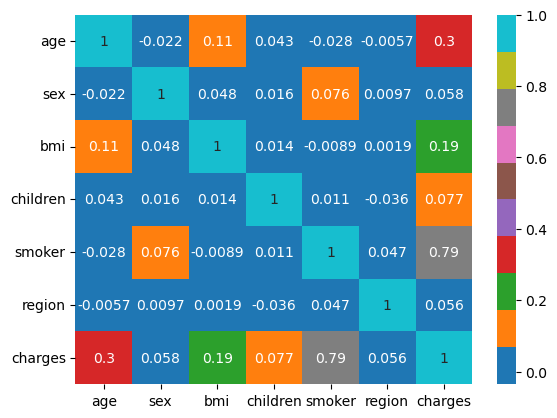

In [ ]:
sns.heatmap(corelation, xticklabels=corelation.columns, yticklabels=corelation.columns, annot=True, cmap=sns.color_palette( as_cmap=True))
plt.show()
# the corelation between smoker and charges is most.Secondly age and charges. that makes sense but when i look at big schema corelation is less.

In [ ]:
new_data_copy.corr().abs()["charges"].nlargest(11) #the order highest corelation between Purchased_Bike and another features

charges     1.000000
smoker      0.785617
age         0.304561
bmi         0.185410
children    0.076993
sex         0.057519
region      0.056311
Name: charges, dtype: float64

C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


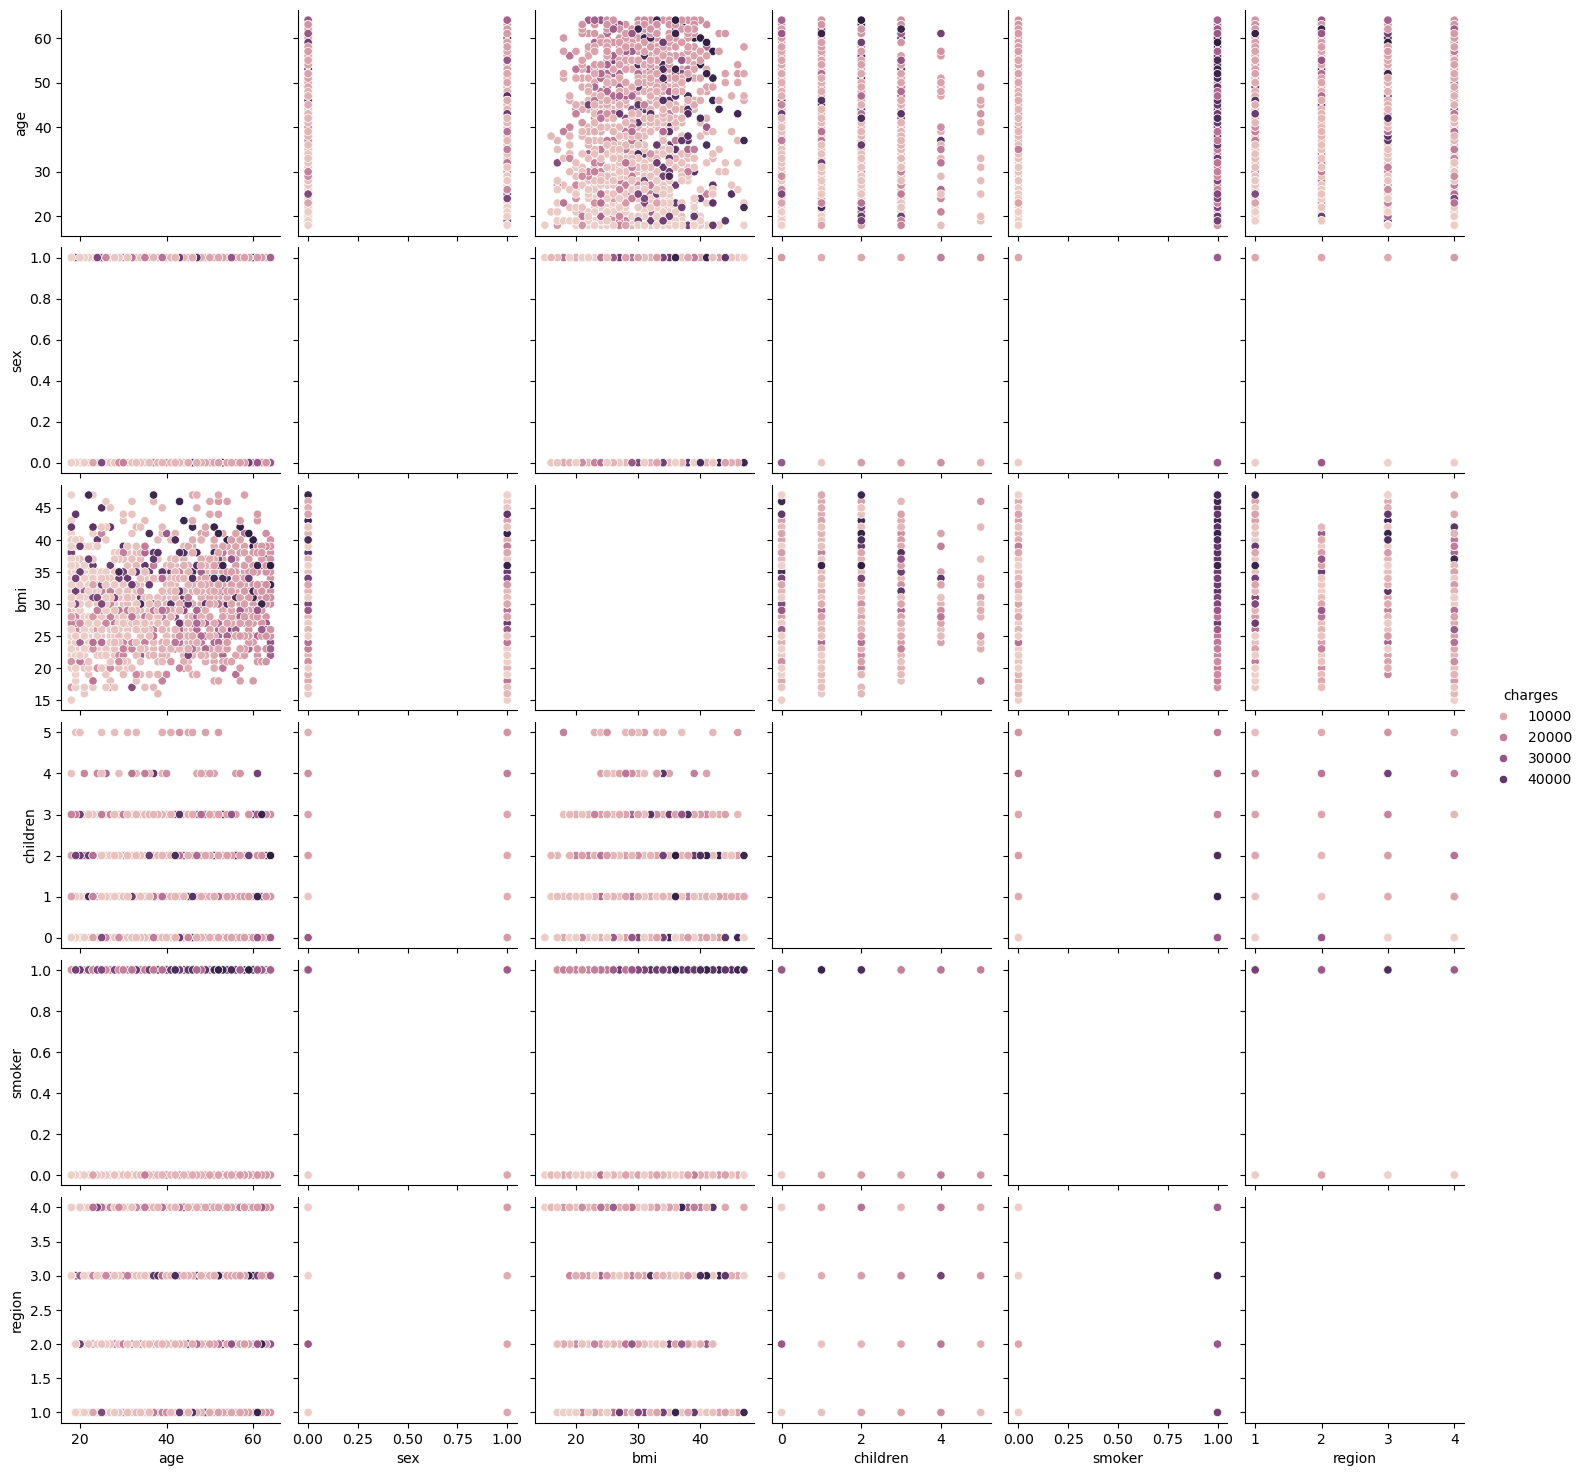

In [ ]:
sns.pairplot(data=new_data_copy, hue='charges')# This is showing scatter plot of all features between charges
plt.show()
#When i look at this matrix there is no corelattion between columns.

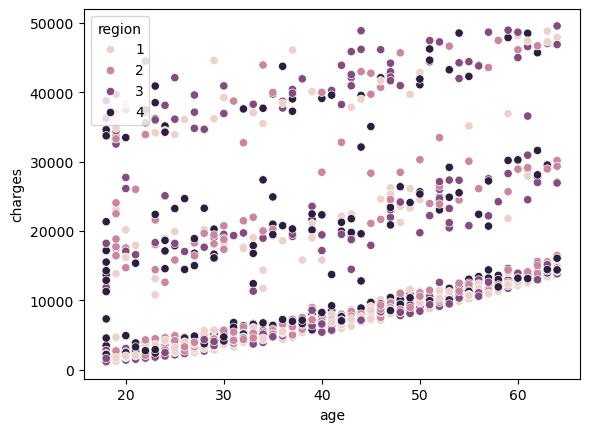

In [ ]:
species = list(new_data_copy.groupby('region'))
sns.scatterplot(data = new_data_copy, x = 'age', y = 'charges', hue='region')
plt.show()


In [ ]:
# Aim: is there any relation cjhildren   and smoker ?
dd = pd.crosstab(new_data_copy['children'], new_data_copy['smoker'], margins=True)
dd
#True False Table.

smoker,0,1,All
children,,,
0,459,111,570
1,263,59,322
2,185,55,240
3,118,38,156
4,22,3,25
5,17,1,18
All,1064,267,1331


In [ ]:

# Initialize expected frequencies matrix
e = np.zeros((6, 2))
summ = dd.loc['All', 'All']
rows = dd.index[:-1]  # Exclude the 'All' row
cols = dd.columns[:-1]  # Exclude the 'All' column

# Calculate expected frequencies
for i in range(len(rows)):
    for j in range(len(cols)):
        e[i, j] = (dd.loc['All', cols[j]] * dd.loc[rows[i], 'All']) / summ

# Convert real frequencies to numpy array
real = pd.crosstab(new_data_copy['children'], new_data_copy['smoker']).to_numpy()

# Chi-square calculation
chi_square = np.sum((real - e)**2 / e)
print(chi_square)

7.121465423990419


In [ ]:
from scipy.stats import chi2

# Chi-kare istatistiği
chi_square_statistic =6.887719904947631

# Serbestlik derecesi
degrees_of_freedom = 1  # Örneğin, iki kategorik değişken olduğunda, serbestlik derecesi kategori sayısının bir eksikliğidir.

# P-değeri
p_value = 1 - chi2.cdf(chi_square_statistic, degrees_of_freedom)

print("P-değer:", p_value)


P-değer: 0.008678990332652958


Calculated p-value: 0.0087

Since 0.0087 is less than 0.05, you reject the null hypothesi
there is no relations.

In [ ]:
new_data_copy.groupby(['sex', 'smoker']).size().unstack(fill_value=0)

smoker,0,1
sex,,
0,547,112
1,517,155


In [ ]:
new_data_copy.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27,0,1,1,16884.92400
1,18,1,33,1,0,3,1725.55230
2,28,1,33,3,0,3,4449.46200
3,33,1,22,0,0,2,21984.47061
4,32,1,28,0,0,2,3866.85520


In [ ]:
s=new_data_copy[new_data_copy['age']<30]
print("Count of YOUNG people in belong this region ", s["region"].value_counts())

Count of YOUNG people in belong this region  region
3    115
2    102
4    101
1     98
Name: count, dtype: int64


In [ ]:
j=new_data_copy[new_data_copy['age']>50]
print("Count of OLD people  in belong this region", j["region"].value_counts())

Count of OLD people  in belong this region region
3    93
4    87
1    87
2    86
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = new_data_copy.drop('charges', axis=1)
y = new_data_copy['charges']

# Veriyi eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Performans değerlendirme fonksiyonu
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return mae, mse, rmse, r2, y_pred

In [ ]:
# Create a Linear Regression model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

results = {}

mae, mse, rmse, r2,y_pred_lr = evaluate_model(lr, X_train, y_train, X_test, y_test)
results[lr] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}


In [ ]:

print("Lineer Regresyon")
for models,metrics in results.items():
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")
    print("\n")

Lineer Regresyon
MAE: 4196.7255
MSE: 35554223.7015
RMSE: 5962.7363
R2: 0.7761




2. Decision Tree

In [ ]:
# Create a Linear Regression model
from sklearn.tree import DecisionTreeRegressor
dc = DecisionTreeRegressor()

In [ ]:

results = {}

mae, mse, rmse, r2, y_pred_d = evaluate_model(dc, X_train, y_train, X_test, y_test)
results[dc] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

In [ ]:

print("Decision Tree Regresyon")
for models,metrics in results.items():
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")
    print("\n")

Decision Tree Regresyon
MAE: 3123.8167
MSE: 42975791.7082
RMSE: 6555.5924
R2: 0.7293




3. Random Forest

In [ ]:
# Create a Linear Regression model
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()

In [ ]:

results = {}
mae, mse, rmse, r2,y_pred_rf  = evaluate_model(rf, X_train, y_train, X_test, y_test)
results[models] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

In [ ]:

print("Random Forest Regresyon")
for models,metrics in results.items():
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")
    print("\n")

Random Forest Regresyon
MAE: 2593.9552
MSE: 21861164.2980
RMSE: 4675.5924
R2: 0.8623




### TUNING

1. Linear Regresyon

In [ ]:
param_grid_lr = {
    'fit_intercept': [True, False]
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(LinearRegression(), param_grid_lr, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [ ]:

# Hiper-parametre optimizasyonu
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print(f"Best parameters for {lr}: {grid_search.best_params_}")


Best parameters for LinearRegression(): {'fit_intercept': True}


In [ ]:
# Optimize edilmiş modelleri değerlendirme
optimized_results={}
mae, mse, rmse, r2,y_pred_lr = evaluate_model(lr, X_train, y_train, X_test, y_test)
optimized_results[lr] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}
# Sonuçları karşılaştırma
print("Optimize Edilmiş Modeller Sonuçları")

print(f"{metrics.items()}: {value:.4f}")


Optimize Edilmiş Modeller Sonuçları
dict_items([('MAE', 2593.955182779603), ('MSE', 21861164.29803258), ('RMSE', 4675.592400758708), ('R2', 0.8623058385230908)]): 0.8623


2. Decision Tree

In [ ]:

param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 10, 20]
}

In [ ]:
grid_searches=GridSearchCV(DecisionTreeRegressor(), param_grid_dt, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [ ]:
# Hiper-parametre optimizasyonu
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print(f"Best parameters for {dc}: {grid_search.best_params_}")

Best parameters for DecisionTreeRegressor(): {'fit_intercept': True}


In [ ]:
# Optimize edilmiş modelleri değerlendirme

mae, mse, rmse, r2,y_pred_dc = evaluate_model(dc, X_train, y_train, X_test, y_test)
optimized_results[dc] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}
# Sonuçları karşılaştırma
print("Optimize Edilmiş Modeller Sonuçları")
print(f"{metrics.items()}: {value:.4f}")


Optimize Edilmiş Modeller Sonuçları
dict_items([('MAE', 2593.955182779603), ('MSE', 21861164.29803258), ('RMSE', 4675.592400758708), ('R2', 0.8623058385230908)]): 0.8623


3. Random Forest

In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 10, 20]
}


In [ ]:
grid_searches= GridSearchCV(RandomForestRegressor(), param_grid_rf, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [ ]:
# Hiper-parametre optimizasyonu
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print(f"Best parameters for {rf}: {grid_search.best_params_}")

Best parameters for RandomForestRegressor(): {'fit_intercept': True}


In [ ]:
# Optimize edilmiş modelleri değerlendirme

mae, mse, rmse, r2 ,y_pred_rf = evaluate_model(dc, X_train, y_train, X_test, y_test)
optimized_results[rf] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

print("Optimize Edilmiş Modeller Sonuçları")
print(f"{metrics.items()}: {value:.4f}")


Optimize Edilmiş Modeller Sonuçları
dict_items([('MAE', 2593.955182779603), ('MSE', 21861164.29803258), ('RMSE', 4675.592400758708), ('R2', 0.8623058385230908)]): 0.8623


In [ ]:


compare_rf = pd.DataFrame({"Actual": y_test.ravel(), "Predicted_RF": y_pred_rf.ravel()})
compare_optimized_rf = pd.DataFrame({"Actual": y_test.ravel(), "Predicted_Optimized_RF": y_pred_rf.ravel()})


In [ ]:
compare = pd.DataFrame({"Actual": y_test.ravel(), "Predicted": y_pred_rf.ravel()})
compare.head()

,Actual,Predicted
0,11534.87265,11833.7823
1,3693.42800,3987.9260
2,3238.43570,3766.8838
3,38746.35510,38282.7495
4,4058.71245,19442.3535


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


lr_unoptimized = LinearRegression()
lr_unoptimized.fit(X_train, y_train)
y_pred_lr_unoptimized = lr_unoptimized.predict(X_test)
mse_unoptimized = mean_squared_error(y_test, y_pred_lr_unoptimized)


param_grid_lr = {
    'fit_intercept': [True, False]
}


grid_search_lr = GridSearchCV(LinearRegression(), param_grid_lr, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_lr.fit(X_train, y_train)
best_lr = grid_search_lr.best_estimator_


best_lr.fit(X_train, y_train)
y_pred_lr_optimized = best_lr.predict(X_test)
mse_optimized = mean_squared_error(y_test, y_pred_lr_optimized)


print("MSE for Unoptimized Linear Regression:", mse_unoptimized)
print("MSE for Optimized Linear Regression:", mse_optimized)


MSE for Unoptimized Linear Regression: 35554223.70148949
MSE for Optimized Linear Regression: 35554223.70148949


In [ ]:
from scipy import stats


t_statistic_lr, p_value_lr = stats.ttest_rel(y_pred_lr_unoptimized, y_pred_lr_optimized)
print("T-statistic for Linear Regression:", t_statistic_lr)
print("P-value for Linear Regression:", p_value_lr)


T-statistic for Linear Regression: nan
P-value for Linear Regression: nan


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from scipy import stats


dc_unoptimized = DecisionTreeRegressor(random_state=42)

# Fit and evaluate the unoptimized model
dc_unoptimized.fit(X_train, y_train)
y_pred_dc_unoptimized = dc_unoptimized.predict(X_test)
mse_unoptimized = mean_squared_error(y_test, y_pred_dc_unoptimized)

# Create a Decision Tree Regressor model with hyperparameter optimization
param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 10, 20]
}
grid_search_dc = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid_dt, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_dc.fit(X_train, y_train)
best_dc = grid_search_dc.best_estimator_

# Fit and evaluate the optimized model
best_dc.fit(X_train, y_train)
y_pred_dc_optimized = best_dc.predict(X_test)
mse_optimized = mean_squared_error(y_test, y_pred_dc_optimized)

# Print MSE scores for both models
print("MSE for Unoptimized Decision Tree Regressor:", mse_unoptimized)
print("MSE for Optimized Decision Tree Regressor:", mse_optimized)

# Perform a hypothesis test to compare the MSEs of the two models
t_statistic, p_value = stats.ttest_rel(y_pred_dc_unoptimized, y_pred_dc_optimized)
print("T-statistic:", t_statistic)
print("P-value:", p_value)


MSE for Unoptimized Decision Tree Regressor: 44621144.36139836
MSE for Optimized Decision Tree Regressor: 23306867.76761892
T-statistic: 2.4426530458805793
P-value: 0.0152308991832577


In [ ]:
0.05>0.015

True

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

# Özellik Seçimi - RFE
rfe = RFE(estimator=RandomForestRegressor(), n_features_to_select=5)
rfe.fit(X_train, y_train)
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)



In [ ]:
from sklearn.decomposition import PCA


# PCA
pca = PCA(n_components=5)
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)



In [ ]:


lr = LinearRegression()

lr.fit(X_train_rfe, y_train)
y_pred_lr_rfe = lr.predict(X_test_rfe)
mse_lr_rfe = mean_squared_error(y_test, y_pred_lr_rfe)


lr.fit(X_train_pca, y_train)
y_pred_lr_pca = lr.predict(X_test_pca)
mse_lr_pca = mean_squared_error(y_test, y_pred_lr_pca)


print("MSE for Linear Regression with RFE:", mse_lr_rfe)
print("MSE for Linear Regression with PCA:", mse_lr_pca)

MSE for Linear Regression with RFE: 35561786.96298783
MSE for Linear Regression with PCA: 140612342.50205714


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# Özellik Seçimi - RFE
rfe = RFE(estimator=DecisionTreeRegressor(), n_features_to_select=5)
rfe.fit(X_train, y_train)
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

# Özellik Seçimi - Feature Importance
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
importances = dt.feature_importances_
selected_features_importance = X_train.columns[np.argsort(importances)[::-1][:5]]
X_train_importance = X_train[selected_features_importance]
X_test_importance = X_test[selected_features_importance]

# PCA
pca = PCA(n_components=5)
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)


dt = DecisionTreeRegressor(random_state=42)


dt.fit(X_train_rfe, y_train)
y_pred_dt_rfe = dt.predict(X_test_rfe)
mse_dt_rfe = mean_squared_error(y_test, y_pred_dt_rfe)

#
dt.fit(X_train_importance, y_train)
y_pred_dt_importance = dt.predict(X_test_importance)
mse_dt_importance = mean_squared_error(y_test, y_pred_dt_importance)

#
dt.fit(X_train_pca, y_train)
y_pred_dt_pca = dt.predict(X_test_pca)
mse_dt_pca = mean_squared_error(y_test, y_pred_dt_pca)


print("MSE for Decision Tree with RFE:", mse_dt_rfe)
print("MSE for Decision Tree with Feature Importance:", mse_dt_importance)
print("MSE for Decision Tree with PCA:", mse_dt_pca)


MSE for Decision Tree with RFE: 38187108.32836946
MSE for Decision Tree with Feature Importance: 38187108.32836946
MSE for Decision Tree with PCA: 47534516.33757679
